<a href="https://colab.research.google.com/github/AnumahAdeizaStephen/ResNet-Tutorial-/blob/main/Network_y%3Dtop%20to%20bottom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Mounted at /content/drive
Creating dataset (IMPORTANT: force_rebuild_cache=True to ensure new coord convention applies)...

LOADING AND AGGREGATING 2 BIN FILES


Processing BIN files:   0%|          | 0/2 [00:00<?, ?it/s]

  Parsing binary file: scan_x16.000_y11.000_2026-03-03__19_57_13.bin


Processing BIN files:  50%|█████     | 1/2 [00:14<00:14, 14.24s/it]


  Position (16.0, 11.0):
    • Events: 14,094
    • Hits: 63,130
    • Active pixels: 121/121
    • Max hits/pixel: 3355
    • Max amplitude: 7831.7
  Parsing binary file: scan_x5.000_y11.000_2026-03-03__20_19_28.bin


Processing BIN files: 100%|██████████| 2/2 [00:26<00:00, 13.23s/it]


  Position (5.0, 11.0):
    • Events: 10,534
    • Hits: 47,564
    • Active pixels: 121/121
    • Max hits/pixel: 940
    • Max amplitude: 7439.3

NORMALIZING AMPLITUDE MAPS
  ✓ Normalized 2 amplitude maps

FILTERING POSITIONS (min hits: 10)
  Keeping 2/2 positions with ≥ 10 hits

✓ Created aggregated dataset with 2 positions
  • Target type: amplitude
  • Amplitude normalization: True
  • Min hits threshold: 10
  • Grid size: 11x11
  • Coordinate convention (MODEL): y=0 at TOP row

Dataset created with 2 samples


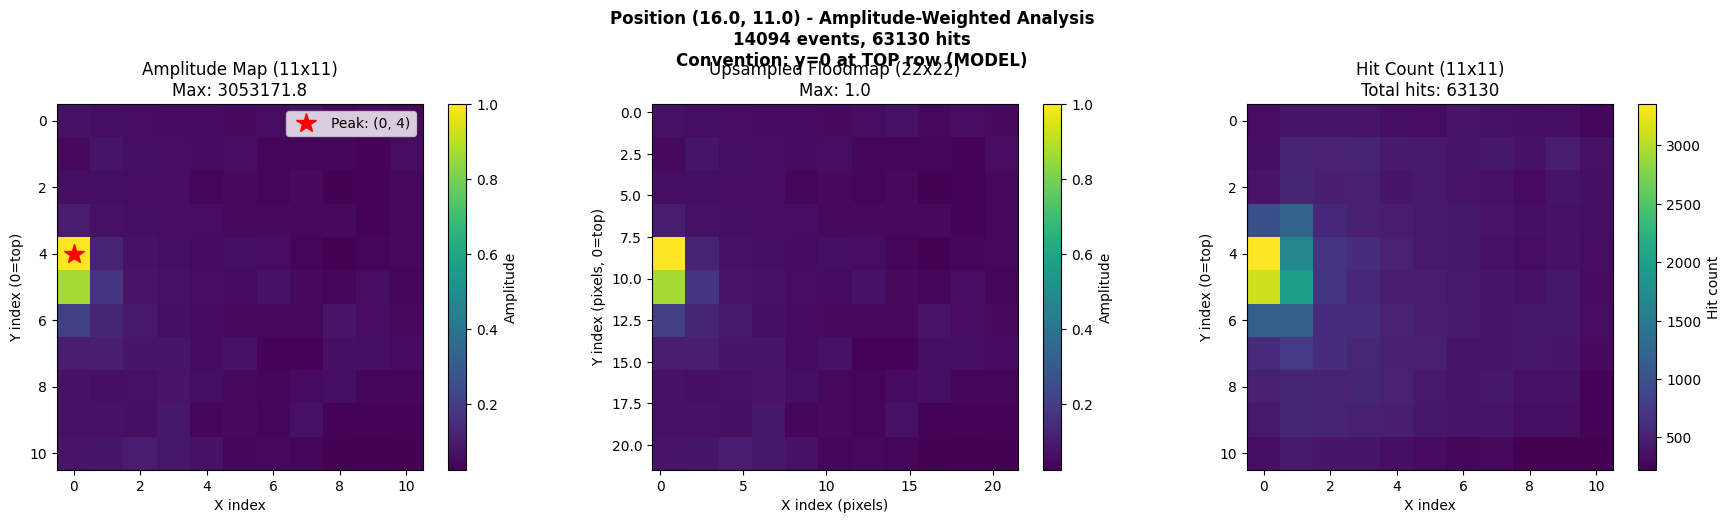

AMPLITUDE-WEIGHTED PEAK ANALYSIS (MODEL COORDS: y=0 at TOP)
Physical Y   Peak X     Peak Y     Max Amp      Total Amp   
--------------------------------------------------------------------------------
11.0         0          4          1.0          9.1         
11.0         0          0          1.0          24.5        
Input shape: torch.Size([2, 1, 22, 22])
Output shape: torch.Size([2, 2])
Position range - X: [5.0, 16.0], Y: [11.0, 11.0]
Augmented dataset size: 12

TRAINING MODEL
NaN loss at epoch 1! Stopping.
Training done.


In [1]:
import os
import re
import gc
import yaml
import pickle
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from scipy.ndimage import zoom

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)


# -----------------------
# Optional Colab drive mount
# -----------------------
def maybe_mount_colab_drive(mount_point="/content/drive"):
    try:
        from google.colab import drive  # type: ignore
        drive.mount(mount_point)
        return True
    except Exception:
        return False


# -----------------------
# Config
# -----------------------
CONFIG = "/content/config.yaml"  # adjust if not on colab
if os.path.exists(CONFIG):
    CFG = yaml.safe_load(open(CONFIG))
else:
    CFG = None  # allow script import without config existing


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# -----------------------
# Dataset
# -----------------------
class AggregatedRasterDataset:
    """
    Aggregates many BIN files into:
      - sparse_floodmaps: (N, 11, 11) amplitude-sum maps
      - aggregated_floodmaps: (N, 22, 22) upsampled maps
      - hit_counts: (N, 11, 11) counts

    IMPORTANT: This version enforces a "model coordinate system":
      - x_idx = 0..10 left->right
      - y_idx = 0..10 TOP->BOTTOM (i.e. top row is y_idx=0)

    That is achieved by flipping detector y during aggregation:
      y_idx = (grid_size - 1) - (detector_y - 1)
            = grid_size - detector_y
    """

    def __init__(
        self,
        bin_file_paths,
        config_path=CONFIG,
        target_type="amplitude",
        filter_empty=True,
        max_samples=None,
        min_hits_threshold=10,
        normalize_amplitude=True,
        normalize_method="minmax",
        verbose=True,
        grid_size=11,
        force_rebuild_cache=False,
        cache_dir=".",
    ):
        if config_path is None:
            raise ValueError("config_path must be provided (path to YAML config).")
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Config not found at {config_path}")

        self.bin_file_paths = list(bin_file_paths)
        self.config = yaml.safe_load(open(config_path, "r"))

        self.target_type = target_type
        self.filter_empty = filter_empty
        self.max_samples = max_samples
        self.min_hits_threshold = min_hits_threshold
        self.normalize_amplitude = normalize_amplitude
        self.normalize_method = normalize_method
        self.verbose = verbose

        self.grid_size = int(grid_size)
        self.force_rebuild_cache = bool(force_rebuild_cache)
        self.cache_dir = Path(cache_dir)

        # Store aggregated data
        self.aggregated_floodmaps = []  # List of (22, 22) floodmaps
        self.sparse_floodmaps = []      # List of (11, 11) floodmaps (amplitude-weighted)
        self.hit_counts = []            # List of (11, 11) hit count matrices (for reference only)
        self.positions = []             # List of (x, y) positions from filename
        self.metadata = []              # Metadata per position
        self.amplitude_stats = []       # Store normalization stats

        self.load_and_aggregate_all_files()

        if self.normalize_amplitude:
            self._normalize_amplitude_maps()

        if self.filter_empty:
            self._filter_empty_positions()

        if self.max_samples is not None and self.max_samples < len(self.aggregated_floodmaps):
            self._limit_samples()

        if self.verbose:
            print(f"\n✓ Created aggregated dataset with {len(self.aggregated_floodmaps)} positions")
            print(f"  • Target type: {self.target_type}")
            print(f"  • Amplitude normalization: {self.normalize_amplitude}")
            print(f"  • Min hits threshold: {self.min_hits_threshold}")
            print(f"  • Grid size: {self.grid_size}x{self.grid_size}")
            print("  • Coordinate convention (MODEL): y=0 at TOP row")

    def clear_cache_for_bin(self, bin_file_path):
        """Delete the cached .npy file for a given bin file."""
        full_path = str(Path(bin_file_path).resolve())
        h = hashlib.md5(full_path.encode("utf-8")).hexdigest()[:10]
        outfilename = self.cache_dir / f"{Path(bin_file_path).stem}_{h}.npy"
        if outfilename.exists():
            outfilename.unlink()
            if self.verbose:
                print(f"Deleted cache: {outfilename}")

    def _normalize_amplitude_maps(self):
        if self.verbose:
            print(f"\n{'='*60}")
            print("NORMALIZING AMPLITUDE MAPS")
            print(f"{'='*60}")

        self.amplitude_stats = []

        for i in range(len(self.sparse_floodmaps)):
            max_amp = float(np.max(self.sparse_floodmaps[i]))
            total_amp = float(np.sum(self.sparse_floodmaps[i]))
            total_hits = int(np.sum(self.hit_counts[i]))

            self.amplitude_stats.append(
                {
                    "max_amplitude": max_amp,
                    "total_amplitude": total_amp,
                    "mean_amplitude": (total_amp / total_hits) if total_hits > 0 else 0.0,
                }
            )

            if max_amp > 0:
                self.sparse_floodmaps[i] = self.sparse_floodmaps[i] / max_amp
                self.aggregated_floodmaps[i] = self.aggregated_floodmaps[i] / max_amp
            else:
                if self.verbose:
                    print(f"  Warning: Position {self.positions[i]} has zero amplitude (no normalization applied)")

        if self.verbose:
            print(f"  ✓ Normalized {len(self.sparse_floodmaps)} amplitude maps")

    def load_and_aggregate_all_files(self):
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"LOADING AND AGGREGATING {len(self.bin_file_paths)} BIN FILES")
            print(f"{'='*60}")

        for file_idx, bin_file in enumerate(
            tqdm(self.bin_file_paths, desc="Processing BIN files", disable=not self.verbose)
        ):
            data = self._load_single_bin_file(bin_file)

            floodmap_sparse, floodmap_upsampled, hit_count, stats = self._aggregate_events_to_floodmap(data)

            position = self._extract_position_from_filename(bin_file)

            self.sparse_floodmaps.append(floodmap_sparse)
            self.aggregated_floodmaps.append(floodmap_upsampled)
            self.hit_counts.append(hit_count)
            self.positions.append(position)
            self.metadata.append(
                {
                    "file_path": bin_file,
                    "position": position,
                    "total_events": data["num_events"],
                    "total_hits": stats["total_hits"],
                    "active_pixels": stats["active_pixels"],
                    "max_hits_in_pixel": stats["max_hits"],
                    "max_amplitude": stats["max_amplitude"],
                    "mean_amplitude": stats["mean_amplitude"],
                    "file_index": file_idx,
                    "coord_convention": "MODEL: y=0 at TOP row (flipped during aggregation)",
                }
            )

            if self.verbose and file_idx < 5:
                print(f"\n  Position ({position[0]:.1f}, {position[1]:.1f}):")
                print(f"    • Events: {data['num_events']:,}")
                print(f"    • Hits: {stats['total_hits']:,}")
                print(f"    • Active pixels: {stats['active_pixels']}/{self.grid_size*self.grid_size}")
                print(f"    • Max hits/pixel: {stats['max_hits']}")
                print(f"    • Max amplitude: {stats['max_amplitude']:.1f}")

    def _cache_filename(self, bin_file_path):
        full_path = str(Path(bin_file_path).resolve())
        h = hashlib.md5(full_path.encode("utf-8")).hexdigest()[:10]
        return self.cache_dir / f"{Path(bin_file_path).stem}_{h}.npy"

    def _load_single_bin_file(self, bin_file_path):
        outfilename = self._cache_filename(bin_file_path)

        if outfilename.exists() and not self.force_rebuild_cache:
            if self.verbose:
                print(f"  Loading cached data from {Path(bin_file_path).name}")
            with open(outfilename, "rb") as f:
                file_size = np.load(f)
                record_size = np.load(f)
                num_records = np.load(f)
                waveforms = np.load(f)
                timestamp = np.load(f)
                x = np.load(f)
                y = np.load(f)
                channel_flag = np.load(f)
        else:
            if self.verbose:
                if outfilename.exists() and self.force_rebuild_cache:
                    print(f"  Cache ignored (force_rebuild_cache=True). Re-parsing: {Path(bin_file_path).name}")
                else:
                    print(f"  Parsing binary file: {Path(bin_file_path).name}")

            data_type = np.dtype(
                [
                    ("length", ">u2"),
                    ("log_type", ">u2"),
                    ("packet_count", ">u2"),
                    ("packet_flags", ">u1"),
                    ("system_number", ">u1"),
                    ("timestamp", ">u8"),
                    ("source_id", ">u1"),
                    ("trig_type", ">u1"),
                    ("user_status", ">u2"),
                    ("event_id", ">u4"),
                    ("pps_timestamp", ">u4"),
                    ("channel_flag", ">u1"),
                    ("cell_pointer", ">u1"),
                    ("x_address", ">u1"),
                    ("y_address", ">u1"),
                    ("waveforms", (">H", (160,))),
                ]
            )

            file_size = os.path.getsize(bin_file_path)
            record_size = 32 + 160 * 2
            num_records = file_size // record_size
            memmap = np.memmap(bin_file_path, dtype=data_type, mode="r", shape=(num_records,))

            # Handle timestamp overflow
            prev_timestamp = int(memmap["timestamp"][0])
            overflow_increment = 0
            adjusted_timestamps = np.zeros_like(memmap["timestamp"])
            for i, ts in enumerate(memmap["timestamp"]):
                ts_int = int(ts)
                if ts_int < prev_timestamp:
                    overflow_increment += prev_timestamp
                adjusted_timestamps[i] = ts_int + overflow_increment
                prev_timestamp = ts_int

            waveforms = memmap["waveforms"].byteswap().view(memmap["waveforms"].dtype.newbyteorder())
            timestamp = adjusted_timestamps.byteswap().view(adjusted_timestamps.dtype.newbyteorder())
            x = memmap["x_address"].byteswap().view(memmap["x_address"].dtype.newbyteorder())
            y = memmap["y_address"].byteswap().view(memmap["y_address"].dtype.newbyteorder())
            channel_flag = memmap["channel_flag"].byteswap().view(memmap["channel_flag"].dtype.newbyteorder())

            # Cache the parsed arrays
            self.cache_dir.mkdir(parents=True, exist_ok=True)
            with open(outfilename, "wb") as f:
                np.save(f, file_size)
                np.save(f, record_size)
                np.save(f, num_records)
                np.save(f, waveforms)
                np.save(f, timestamp)
                np.save(f, x)
                np.save(f, y)
                np.save(f, channel_flag)

        # Group hits by timestamp (events)
        df = pd.DataFrame(
            {
                "timestamp": timestamp,
                "x": x,
                "y": y,
                "channel_flag": channel_flag,
                "waveform_idx": np.arange(len(waveforms), dtype=np.int32),
            }
        )

        event_groups = df.groupby("timestamp")

        event_data = []
        for ts, group_df in event_groups:
            event_waveforms = []
            for _, row in group_df.iterrows():
                waveform_idx = int(row["waveform_idx"])
                w = waveforms[waveform_idx].astype(np.float32)
                event_waveforms.append(
                    {
                        "waveform": w,
                        "x": int(row["x"]),
                        "y": int(row["y"]),
                        "channel_flag": int(row["channel_flag"]),
                        "waveform_idx": waveform_idx,
                    }
                )
            event_data.append({"timestamp": ts, "waveforms": event_waveforms, "num_hits": len(event_waveforms)})

        return {
            "waveforms": waveforms,
            "timestamp": timestamp,
            "x": x,
            "y": y,
            "channel_flag": channel_flag,
            "event_data": event_data,
            "num_events": len(event_groups),
            "num_records": int(num_records),
        }

    def _aggregate_events_to_floodmap(self, data):
        N = self.grid_size
        sparse_map = np.zeros((N, N), dtype=np.float32)
        hit_count = np.zeros((N, N), dtype=np.int32)

        total_hits = 0
        max_amplitude_global = 0.0
        amplitude_sum_global = 0.0

        wcfg = self.config["waveform"]
        lo0, lo1 = wcfg["anode_low_lim"]
        hi0, hi1 = wcfg["anode_high_lim"]

        for event in data["event_data"]:
            for hit in event["waveforms"]:
                if hit["channel_flag"] not in (1, 3):
                    continue

                # Detector coordinates are assumed 1..N.
                # Model coordinates we want:
                #   x_idx = x-1 (left->right)
                #   y_idx = N - y  (TOP row becomes y_idx=0)
                x_idx = int(hit["x"]) - 1
                y_idx = N - int(hit["y"])

                if not (0 <= x_idx < N and 0 <= y_idx < N):
                    continue

                w = hit["waveform"]

                low = float(np.mean(w[lo0:lo1]))
                high = float(np.mean(w[hi0:hi1]))
                amplitude = float(high - low)

                if amplitude <= 0:
                    continue

                sparse_map[y_idx, x_idx] += amplitude
                hit_count[y_idx, x_idx] += 1

                total_hits += 1
                if amplitude > max_amplitude_global:
                    max_amplitude_global = amplitude
                amplitude_sum_global += amplitude

        active_pixels = int(np.sum(hit_count > 0))
        max_hits_in_pixel = int(np.max(hit_count)) if total_hits > 0 else 0
        mean_amplitude = float(amplitude_sum_global / total_hits) if total_hits > 0 else 0.0

        upsampled_map = self._upsample_map(sparse_map, target_size=(2 * N, 2 * N))

        stats = {
            "total_hits": int(total_hits),
            "active_pixels": active_pixels,
            "max_hits": max_hits_in_pixel,
            "max_amplitude": float(max_amplitude_global),
            "mean_amplitude": mean_amplitude,
        }

        return sparse_map, upsampled_map, hit_count, stats

    def _upsample_map(self, sparse_map, target_size=(22, 22)):
        """Upsample using nearest neighbor."""
        zoom_factors = (
            target_size[0] / sparse_map.shape[0],
            target_size[1] / sparse_map.shape[1],
        )
        upsampled = zoom(sparse_map, zoom_factors, order=0)
        return upsampled.astype(np.float32)

    def _extract_position_from_filename(self, filename):
        match = re.search(r"x([-\d.]+)_y([-\d.]+)", str(filename))
        if match:
            return float(match.group(1)), float(match.group(2))
        return 0.0, 0.0

    def _filter_empty_positions(self):
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"FILTERING POSITIONS (min hits: {self.min_hits_threshold})")
            print(f"{'='*60}")

        original_count = len(self.aggregated_floodmaps)

        valid_indices = []
        for i in range(len(self.aggregated_floodmaps)):
            total_hits = int(np.sum(self.hit_counts[i]))
            if total_hits >= self.min_hits_threshold:
                valid_indices.append(i)

        if self.verbose:
            print(f"  Keeping {len(valid_indices)}/{original_count} positions with ≥ {self.min_hits_threshold} hits")

        self.aggregated_floodmaps = [self.aggregated_floodmaps[i] for i in valid_indices]
        self.sparse_floodmaps = [self.sparse_floodmaps[i] for i in valid_indices]
        self.hit_counts = [self.hit_counts[i] for i in valid_indices]
        self.positions = [self.positions[i] for i in valid_indices]
        self.metadata = [self.metadata[i] for i in valid_indices]

        if len(self.amplitude_stats) == original_count:
            self.amplitude_stats = [self.amplitude_stats[i] for i in valid_indices]

    def _limit_samples(self):
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"LIMITING TO {self.max_samples} SAMPLES")
            print(f"{'='*60}")

        self.aggregated_floodmaps = self.aggregated_floodmaps[: self.max_samples]
        self.sparse_floodmaps = self.sparse_floodmaps[: self.max_samples]
        self.hit_counts = self.hit_counts[: self.max_samples]
        self.positions = self.positions[: self.max_samples]
        self.metadata = self.metadata[: self.max_samples]

        if len(self.amplitude_stats) >= self.max_samples:
            self.amplitude_stats = self.amplitude_stats[: self.max_samples]

        if self.verbose:
            print(f"  Selected {len(self.aggregated_floodmaps)} positions")

    def get_data_dict(self):
        return {
            "floodmaps": torch.FloatTensor(np.array(self.aggregated_floodmaps)),  # (N, 22, 22)
            "positions": torch.FloatTensor(np.array(self.positions)),            # (N, 2)
            "hit_counts": self.hit_counts,
            "sparse_floodmaps": self.sparse_floodmaps,
            "metadata": self.metadata,
        }

    def __len__(self):
        return len(self.aggregated_floodmaps)

    def __getitem__(self, idx):
        return {
            "floodmap": torch.FloatTensor(self.aggregated_floodmaps[idx]),
            "position": torch.FloatTensor(self.positions[idx]),
            "hit_count": self.hit_counts[idx],
            "sparse_floodmap": self.sparse_floodmaps[idx],
            "metadata": self.metadata[idx],
        }


# -----------------------
# Visualization
# -----------------------
def plot_amplitude_weighted_analysis(dataset, idx, figsize=(15, 10)):
    floodmap = dataset.aggregated_floodmaps[idx]
    sparse_map = dataset.sparse_floodmaps[idx]
    hit_count = dataset.hit_counts[idx]
    position = dataset.positions[idx]
    metadata = dataset.metadata[idx]

    if hasattr(dataset, "amplitude_stats") and idx < len(dataset.amplitude_stats):
        amp_stats = dataset.amplitude_stats[idx]
    else:
        amp_stats = {"max_amplitude": float(np.max(sparse_map)), "total_amplitude": float(np.sum(sparse_map))}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Position ({position[0]:.1f}, {position[1]:.1f}) - Amplitude-Weighted Analysis\n"
        f"{metadata['total_events']} events, {metadata['total_hits']} hits\n"
        f"Convention: y=0 at TOP row (MODEL)",
        fontsize=12,
        fontweight="bold",
    )

    # For a matrix where y=0 is TOP row, the most intuitive display is origin='upper'.
    # But since you want the *data itself* to treat that corner as y=0, we keep the matrix that way.
    # For display clarity: origin='upper' matches "y increases downward".
    ax1 = axes[0]
    im1 = ax1.imshow(
        sparse_map,
        cmap="viridis",
        origin="upper",
        extent=[-0.5, 10.5, 10.5, -0.5],
        aspect="equal",
    )
    ax1.set_title(f"Amplitude Map (11x11)\nMax: {amp_stats['max_amplitude']:.1f}")
    ax1.set_xlabel("X index")
    ax1.set_ylabel("Y index (0=top)")
    plt.colorbar(im1, ax=ax1, label="Amplitude")

    peak_y, peak_x = np.unravel_index(np.argmax(sparse_map), sparse_map.shape)
    ax1.plot(peak_x, peak_y, "r*", markersize=15, label=f"Peak: ({peak_x}, {peak_y})")
    ax1.legend(loc="upper right")

    ax2 = axes[1]
    im2 = ax2.imshow(
        floodmap,
        cmap="viridis",
        origin="upper",
        extent=[-0.5, 21.5, 21.5, -0.5],
        aspect="equal",
    )
    ax2.set_title(f"Upsampled Floodmap (22x22)\nMax: {np.max(floodmap):.1f}")
    ax2.set_xlabel("X index (pixels)")
    ax2.set_ylabel("Y index (pixels, 0=top)")
    plt.colorbar(im2, ax=ax2, label="Amplitude")

    ax3 = axes[2]
    im3 = ax3.imshow(
        hit_count,
        cmap="viridis",
        origin="upper",
        extent=[-0.5, 10.5, 10.5, -0.5],
        aspect="equal",
    )
    ax3.set_title(f"Hit Count (11x11)\nTotal hits: {metadata['total_hits']}")
    ax3.set_xlabel("X index")
    ax3.set_ylabel("Y index (0=top)")
    plt.colorbar(im3, ax=ax3, label="Hit count")

    plt.tight_layout()
    plt.show()
    return fig


def print_amplitude_peak_analysis(dataset):
    print("AMPLITUDE-WEIGHTED PEAK ANALYSIS (MODEL COORDS: y=0 at TOP)")
    print("=" * 80)
    print(f"{'Physical Y':<12} {'Peak X':<10} {'Peak Y':<10} {'Max Amp':<12} {'Total Amp':<12}")
    print("-" * 80)

    for i in range(len(dataset)):
        floodmap = dataset.sparse_floodmaps[i]
        position = dataset.positions[i]

        peak_y, peak_x = np.unravel_index(np.argmax(floodmap), floodmap.shape)
        max_amp = float(np.max(floodmap))
        total_amp = float(np.sum(floodmap))

        print(f"{position[1]:<12.1f} {peak_x:<10} {peak_y:<10} {max_amp:<12.1f} {total_amp:<12.1f}")


# -----------------------
# Models (kept from your notebook)
# -----------------------
class FloodmapPositionCNN(nn.Module):
    def __init__(self, input_channels=1, input_size=22, output_size=2):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 22->11

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 11->5

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 5->2
        )
        self.flattened_size = 128 * 2 * 2
        self.fc_layers = nn.Sequential(
            nn.Linear(self.flattened_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, output_size),
        )

    def forward(self, x):
        features = self.conv_layers(x)
        features = features.view(features.size(0), -1)
        return self.fc_layers(features)


def train_position_predictor_fixed_v2(dataset, epochs=300, batch_size=7, use_augmentation=True, verbose=True):
    X = torch.FloatTensor(np.array(dataset.aggregated_floodmaps)).unsqueeze(1)
    y = torch.FloatTensor(np.array(dataset.positions))

    y_min = y.min(dim=0)[0]
    y_max = y.max(dim=0)[0]

    x_range = y_max[0] - y_min[0]
    if x_range == 0:
        if verbose:
            print(f"Warning: X position is constant ({y_min[0]:.1f}). Model will predict constant X.")
        y_normalized = torch.zeros_like(y)
        y_normalized[:, 1] = (y[:, 1] - y_min[1]) / (y_max[1] - y_min[1]) if y_max[1] != y_min[1] else y[:, 1]
        y_normalized[:, 0] = 0.5
    else:
        y_normalized = (y - y_min) / (y_max - y_min)

    if verbose:
        print(f"Input shape: {X.shape}")
        print(f"Output shape: {y.shape}")
        print(f"Position range - X: [{y_min[0]:.1f}, {y_max[0]:.1f}], Y: [{y_min[1]:.1f}, {y_max[1]:.1f}]")

    class ImprovedPositionModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.input_norm = nn.BatchNorm2d(1)

            self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(16)
            self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm2d(32)
            self.pool = nn.MaxPool2d(2)

            self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(64)
            self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
            self.bn4 = nn.BatchNorm2d(64)

            self.gap = nn.AdaptiveAvgPool2d(1)

            self.fc1 = nn.Linear(64, 32)
            self.fc2 = nn.Linear(32, 2)
            self.dropout = nn.Dropout(0.2)
            self.relu = nn.ReLU(inplace=True)

        def forward(self, x):
            x = self.input_norm(x)

            x = self.relu(self.bn1(self.conv1(x)))
            x = self.pool(x)  # 22->11

            x = self.relu(self.bn2(self.conv2(x)))
            x = self.pool(x)  # 11->5

            x = self.relu(self.bn3(self.conv3(x)))
            x = self.relu(self.bn4(self.conv4(x)))
            x = self.pool(x)  # 5->2

            x = self.gap(x)  # (B,64,1,1)
            x = x.view(x.size(0), -1)

            x = self.relu(self.fc1(x))
            x = self.dropout(x)
            return self.fc2(x)

    model = ImprovedPositionModel()
    X = X + 1e-6

    if use_augmentation and len(X) > 1:
        X_aug = [X]
        y_aug = [y_normalized]

        noise_level = 0.02
        X_noisy = X + torch.randn_like(X) * noise_level * X.std()
        X_aug.append(X_noisy)
        y_aug.append(y_normalized)

        shifts = [-0.1, -0.05, 0.05, 0.1]
        for shift in shifts:
            y_shifted = y_normalized.clone()
            y_shifted[:, 1] = torch.clamp(y_shifted[:, 1] + shift, 0, 1)
            X_aug.append(X)
            y_aug.append(y_shifted)

        X = torch.cat(X_aug, dim=0)
        y = torch.cat(y_aug, dim=0)

        if verbose:
            print(f"Augmented dataset size: {len(X)}")

    indices = np.random.permutation(len(X))
    split = int(0.8 * len(X))
    train_idx, val_idx = indices[:split], indices[split:]

    train_dataset = torch.utils.data.TensorDataset(X[train_idx], y[train_idx])
    val_dataset = torch.utils.data.TensorDataset(X[val_idx], y[val_idx])

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    if verbose:
        print(f"\nTRAINING MODEL")
        print(f"{'='*60}")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            if torch.isnan(loss):
                print(f"NaN loss at epoch {epoch+1}! Stopping.")
                return model, None, train_losses, val_losses

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += float(loss.item())

        avg_train_loss = total_train_loss / max(1, len(train_loader))
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                total_val_loss += float(loss.item())

        avg_val_loss = total_val_loss / max(1, len(val_loader))
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= 50:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Predictions on original (non-aug) samples
    model.eval()
    with torch.no_grad():
        X_original = torch.FloatTensor(np.array(dataset.aggregated_floodmaps)).unsqueeze(1) + 1e-6
        y_pred_normalized = model(X_original)

        if x_range == 0:
            y_pred = torch.zeros_like(y_pred_normalized)
            y_pred[:, 0] = y_min[0]
            y_pred[:, 1] = y_pred_normalized[:, 1] * (y_max[1] - y_min[1]) + y_min[1]
        else:
            y_pred = y_pred_normalized * (y_max - y_min) + y_min

    return model, y_pred.numpy(), train_losses, val_losses


# -----------------------
# Main (example)
# -----------------------
if __name__ == "__main__":
    # If on Colab, mount drive (optional)
    maybe_mount_colab_drive()

    # Example BIN list (adjust to your files)
    bin_files = [
        "/content/scan_x16.000_y11.000_2026-03-03__19_57_13.bin",
        "/content/scan_x5.000_y11.000_2026-03-03__20_19_28.bin",
    ]

    print("Creating dataset (IMPORTANT: force_rebuild_cache=True to ensure new coord convention applies)...")
    aggregated_dataset = AggregatedRasterDataset(
        bin_file_paths=bin_files,
        config_path=CONFIG,
        target_type="amplitude",
        filter_empty=True,
        min_hits_threshold=10,
        normalize_amplitude=True,
        verbose=True,
        force_rebuild_cache=True,  # <-- key for your situation
        cache_dir=".",             # cache in current dir
    )

    print(f"\nDataset created with {len(aggregated_dataset)} samples")

    if len(aggregated_dataset) > 0:
        plot_amplitude_weighted_analysis(aggregated_dataset, idx=0)

    print_amplitude_peak_analysis(aggregated_dataset)

    # Train (optional)
    if len(aggregated_dataset) > 0:
        model, y_pred, train_losses, val_losses = train_position_predictor_fixed_v2(
            aggregated_dataset,
            epochs=300,
            batch_size=min(7, len(aggregated_dataset)),
            use_augmentation=True,
            verbose=True,
        )
        print("Training done.")